In [1]:

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import confusion_matrix

import warnings

!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo 

from sklearn.datasets import load_breast_cancer

import pandas as pd


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


# **Section 1**
## **Dataset Selection — Breast Cancer Wisconsin (Diagnostic) (Classification)**

In [2]:

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# **Section 2: Data Understanding and Preprocessing Requirements**

## **Requirement 2.1: Features Identification and Summary**

In [3]:
# Improved Feature Summary Table
feature_summary = pd.DataFrame({
    'Feature': df.columns,
    'Data Type': [df[col].dtype for col in df.columns],
    'Total Values': [df[col].count() for col in df.columns],
    'Unique Values': [df[col].nunique() for col in df.columns],
    'Missing Values': [df[col].isnull().sum() for col in df.columns],
    'Sample Value': [df[col].iloc[0] for col in df.columns],
    'Min Value': [df[col].min() for col in df.columns],
    'Max Value': [df[col].max() for col in df.columns],
    'Mean': [df[col].mean() for col in df.columns],
    'Median': [df[col].median() for col in df.columns],
    'Std Dev': [df[col].std() for col in df.columns],
    'Variance': [df[col].var() for col in df.columns]
})

# Display the enhanced summary table
feature_summary


,Feature,Data Type,Total Values,Unique Values,Missing Values,Sample Value,Min Value,Max Value,Mean,Median,Std Dev,Variance
0,mean radius,float64,569,456,0,17.990000,6.981000,28.11000,14.127292,13.370000,3.524049,12.418920
1,mean texture,float64,569,479,0,10.380000,9.710000,39.28000,19.289649,18.840000,4.301036,18.498909
2,mean perimeter,float64,569,522,0,122.800000,43.790000,188.50000,91.969033,86.240000,24.298981,590.440480
3,mean area,float64,569,539,0,1001.000000,143.500000,2501.00000,654.889104,551.100000,351.914129,123843.554318
4,mean smoothness,float64,569,474,0,0.118400,0.052630,0.16340,0.096360,0.095870,0.014064,0.000198
5,mean compactness,float64,569,537,0,0.277600,0.019380,0.34540,0.104341,0.092630,0.052813,0.002789
6,mean concavity,float64,569,537,0,0.300100,0.000000,0.42680,0.088799,0.061540,0.079720,0.006355
7,mean concave points,float64,569,542,0,0.147100,0.000000,0.20120,0.048919,0.033500,0.038803,0.001506
8,mean symmetry,float64,569,432,0,0.241900,0.106000,0.30400,0.181162,0.179200,0.027414,0.000752
9,mean fractal dimension,float64,569,499,0,0.078710,0.049960,0.09744,0.062798,0.061540,0.007060,0.000050


# **Section 2**
## **Requirement 2.2: Visual Data Exploration**

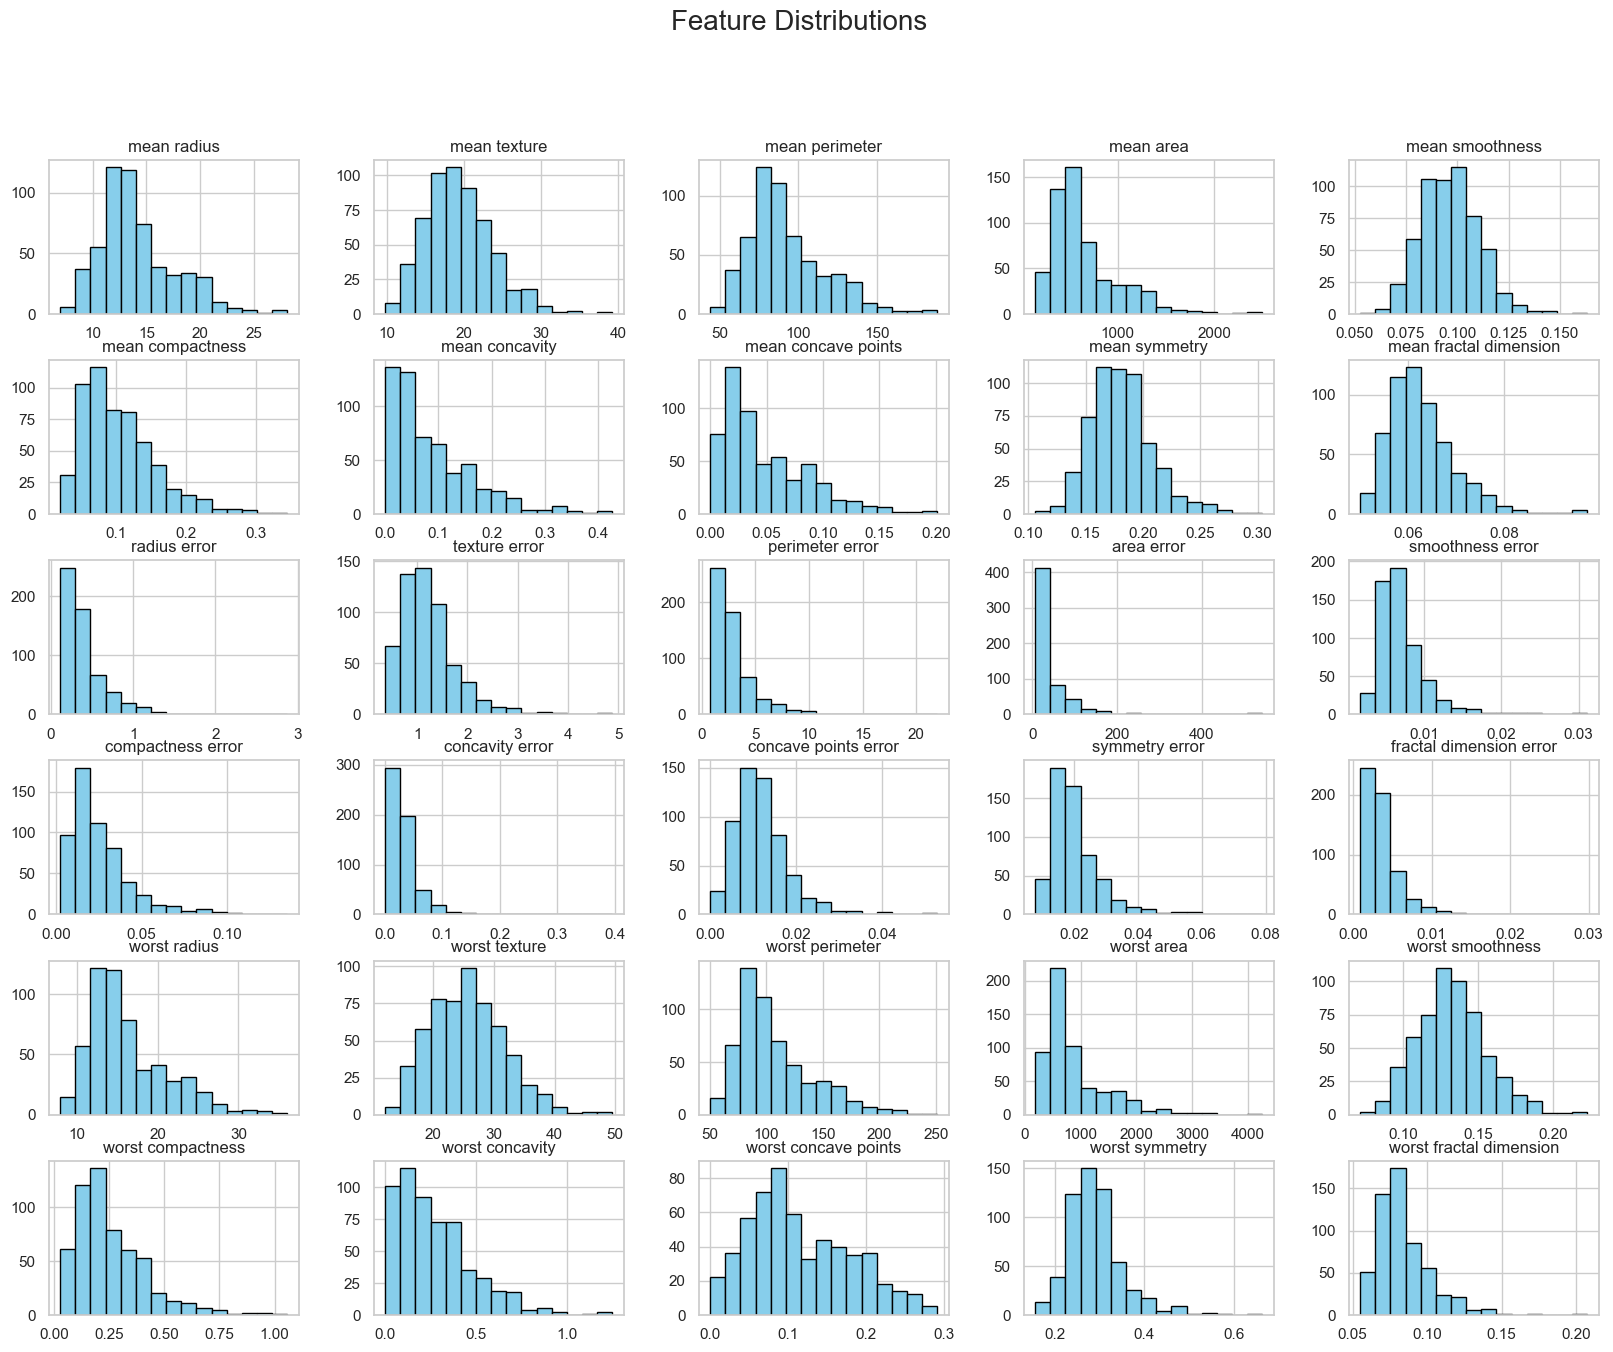

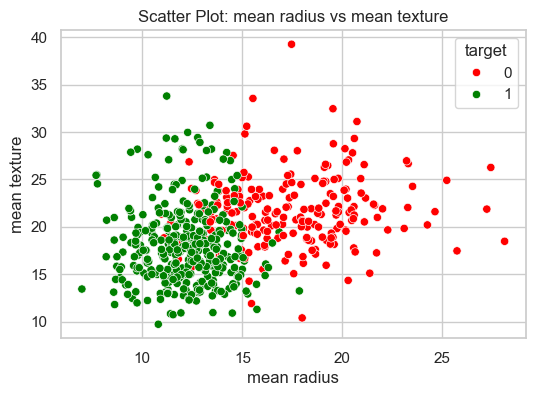

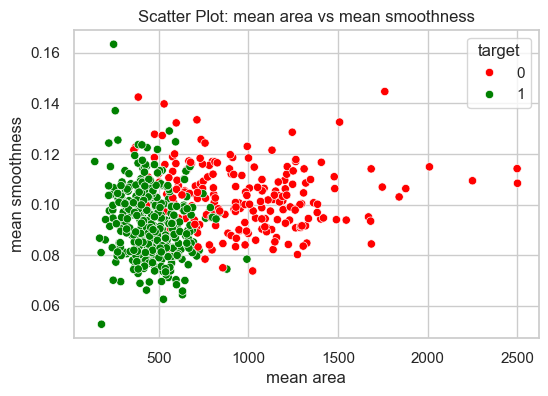

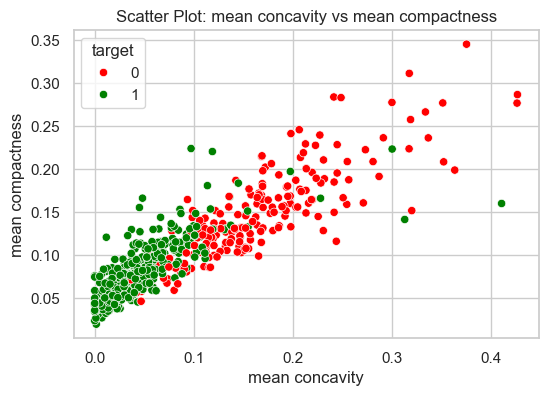

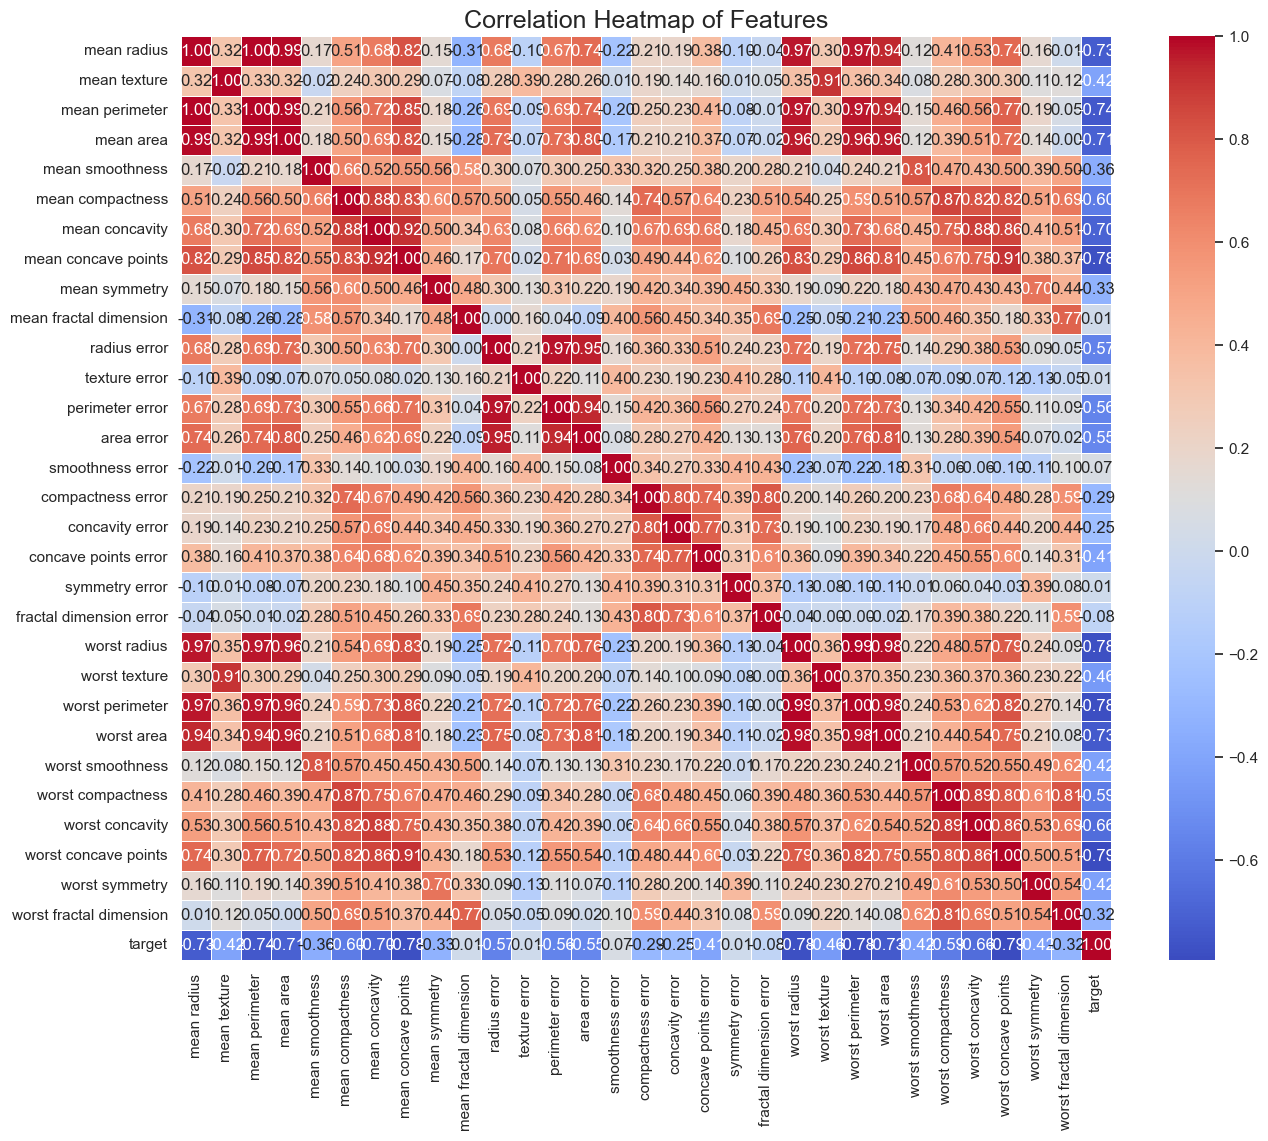

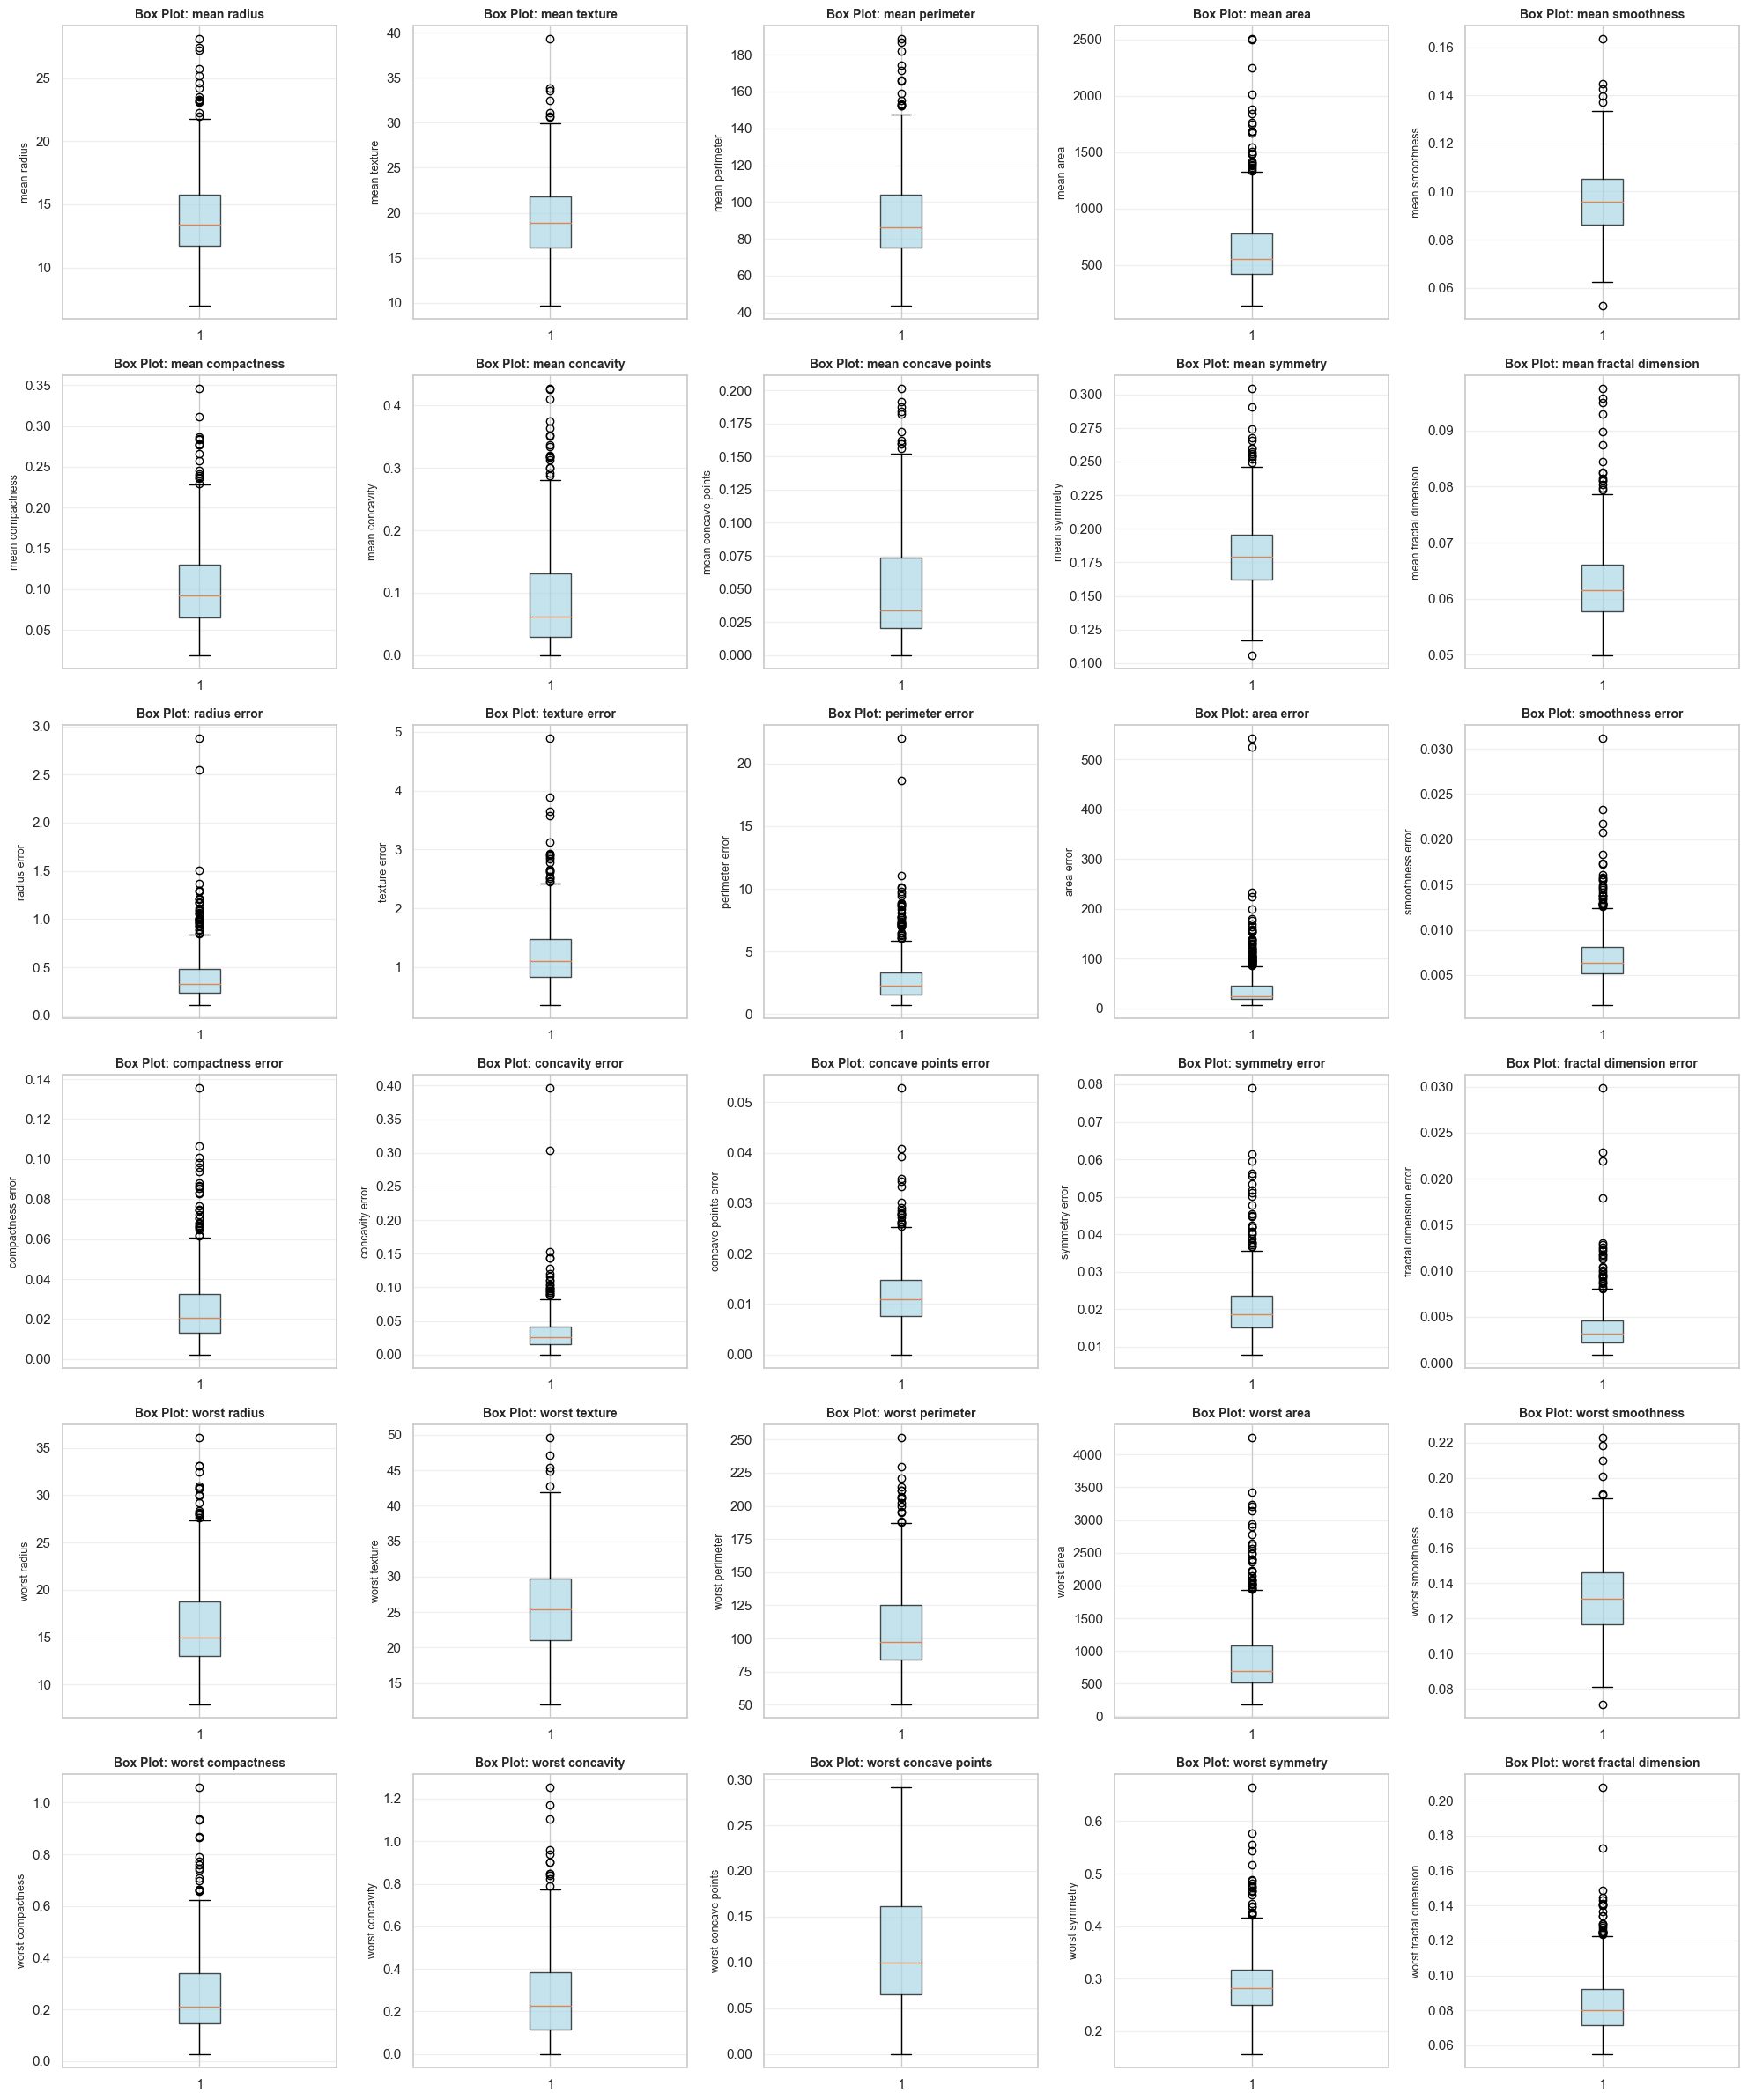

In [4]:
df_copy = df.copy()


sns.set(style="whitegrid")

#drop target because these visualizations are to show the distribution and patterns of the input features.

# 1 Histograms for all features
df_features = df_copy.drop(columns='target')  # Exclude target for histograms
df_features.hist(bins=15, figsize=(20, 15), layout=(6, 5), color='skyblue', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=20)
plt.show()

# 2. Scatter plots for selected feature pairs
feature_pairs = [('mean radius', 'mean texture'), ('mean area', 'mean smoothness'), ('mean concavity', 'mean compactness')]
for x_feat, y_feat in feature_pairs:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=x_feat, y=y_feat, hue='target', palette={0: 'red', 1: 'green'})
    plt.title(f'Scatter Plot: {x_feat} vs {y_feat}')
    plt.show()
j
# 3 Correlation heatmap
plt.figure(figsize=(15, 12))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Features', fontsize=18)
plt.show()

# 4 boxplot 
# Selecting numeric columns (all features except target)
numerical_cols = df_copy.drop(columns='target').columns
n_plots = len(numerical_cols)  # total features
n_cols = 5  # number of columns in grid
n_rows = int(np.ceil(n_plots / n_cols))  # number of rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()  # flatten for easy iteration

# Looping through each numeric feature and create boxplot
for idx, col in enumerate(numerical_cols):
    axes[idx].boxplot(
        df_copy[col].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='lightblue', alpha=0.7)
    )
    axes[idx].set_title(f'Box Plot: {col}', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel(col, fontsize=9)
    axes[idx].grid(True, alpha=0.3, axis='y')

# Removing empty subplots if total plots < grid cells
for idx in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

# **Section 2**
## **Requirement 2.3: Handling Missing Values**

In [5]:
# Requirement 2.3: Handling Missing Values

# Check for missing values in each column
missing_values = df_copy.isnull().sum()
print("Missing values per feature:")
print(missing_values)

# Check if any column has missing values
if missing_values.sum() == 0:
    print("\nNo missing values found. No imputation or removal needed.")
else:
    # if missing values existed we fill with mean
    df_copy.fillna(df_copy.mean(), inplace=True)
    print("\nMissing values were imputed with column mean.")

# Justification:
"""
We decided to fill any missing numeric values with the mean of each feature (mean imputation). This approach is simple
and practical. It keeps the overall distribution of the data intact and ensures we don't lose any
rows, so all available information is used for training the neural network. Since this dataset has 
no missing values, using the mean is an effective and reasonable choice.
"""


Missing values per feature:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

No missing values found. No imputation or removal needed.


"\nWe decided to fill any missing numeric values with the mean of each feature (mean imputation). This approach is simple\nand practical. It keeps the overall distribution of the data intact and ensures we don't lose any\nrows, so all available information is used for training the neural network. Since this dataset has \nno missing values, using the mean is an effective and reasonable choice.\n"

# **Section 2**
## **Requirement 2.4: Statistical Characterization of Numerical Data**

In [6]:
# Select numeric features (exclude target)
numeric_features = df_copy.drop(columns='target')

# Compute descriptive statistics
stats_summary = numeric_features.describe().T  

# Add median
stats_summary['median'] = numeric_features.median()

# Add variance
stats_summary['variance'] = numeric_features.var()

# Add range (max - min)
stats_summary['range'] = numeric_features.max() - numeric_features.min()

# Reorder columns for clarity
stats_summary = stats_summary[['count', 'mean', 'median', 'std', 'variance', 'min', 'max', 'range']]

display(stats_summary)

,count,mean,median,std,variance,min,max,range
mean radius,569.0,14.127292,13.370000,3.524049,12.418920,6.981000,28.11000,21.129000
mean texture,569.0,19.289649,18.840000,4.301036,18.498909,9.710000,39.28000,29.570000
mean perimeter,569.0,91.969033,86.240000,24.298981,590.440480,43.790000,188.50000,144.710000
mean area,569.0,654.889104,551.100000,351.914129,123843.554318,143.500000,2501.00000,2357.500000
mean smoothness,569.0,0.096360,0.095870,0.014064,0.000198,0.052630,0.16340,0.110770
mean compactness,569.0,0.104341,0.092630,0.052813,0.002789,0.019380,0.34540,0.326020
mean concavity,569.0,0.088799,0.061540,0.079720,0.006355,0.000000,0.42680,0.426800
mean concave points,569.0,0.048919,0.033500,0.038803,0.001506,0.000000,0.20120,0.201200
mean symmetry,569.0,0.181162,0.179200,0.027414,0.000752,0.106000,0.30400,0.198000
mean fractal dimension,569.0,0.062798,0.061540,0.007060,0.000050,0.049960,0.09744,0.047480


# **Section 3: Model Implementation Requirements**

## **Requirement 3.1: Data Partitioning**

In [7]:
# Get all columns except last one (features)
X = df_copy.iloc[:, :-1].values

# Get only last column (target)
y = df_copy.iloc[:, -1].values

# Set random seed for reproducibility
#Ensures that the random operations produce the same result every time we run the code.
np.random.seed(42)

# Total number of samples
n_samples = X.shape[0]

# Shuffle the indices
indices = np.random.permutation(n_samples)

# Compute split sizes
train_size = int(0.7 * n_samples)
val_size   = int(0.2 * n_samples)
test_size  = n_samples - train_size - val_size

# Split indices
train_idx = indices[:train_size]
val_idx   = indices[train_size:train_size + val_size]
test_idx  = indices[train_size + val_size:]

# Create datasets
X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val     = X[val_idx], y[val_idx]
X_test, y_test   = X[test_idx], y[test_idx]

# Print shapes to confirm
print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Testing set: {X_test.shape}, {y_test.shape}")


Training set: (398, 30), (398,)
Validation set: (113, 30), (113,)
Testing set: (58, 30), (58,)


# **Section 3**
## **Requirement 3.2: Batching**

In [8]:
# Define batch size
batch_size = 100

# Function to create mini-batches
def mini_batches(X, y, batch_size):
    n_samples = X.shape[0]
    mini_batches = []
    
    for start_idx in range(0, n_samples, batch_size):
        end_idx = min(start_idx + batch_size, n_samples)
        X_batch = X[start_idx:end_idx]
        y_batch = y[start_idx:end_idx]
        mini_batches.append((X_batch, y_batch))
    
    return mini_batches

# Creating mini-batches for training data
train_batches = mini_batches(X_train, y_train, batch_size)

# Printing info about the batches
for i, (X_batch, y_batch) in enumerate(train_batches):
    print(f"Batch {i+1}: {X_batch.shape}, {y_batch.shape}")


Batch 1: (100, 30), (100,)
Batch 2: (100, 30), (100,)
Batch 3: (100, 30), (100,)
Batch 4: (98, 30), (98,)


# **Section 3**
## **Requirement 3.4: Network Architecture**

In [9]:
# # Neural Network Parameters

# input_size = X_train.shape[1]  # 30 features
# hidden_size = 16               # number of neurons in hidden layer (can adjust)
# output_size = 1                # binary output
# learning_rate = 0.01
# n_epochs = 10 

# # Activation Functions Sigmoid because its Binary Classification (1 output)
# def sigmoid(x):
#     return 1 / (1 + np.exp(-x))

# def sigmoid_derivative(x):
#     return x * (1 - x)

# # Initialize weights and biases
# np.random.seed(42)
# W1 = np.random.randn(input_size, hidden_size) * 0.01
# b1 = np.zeros((1, hidden_size))
# W2 = np.random.randn(hidden_size, output_size) * 0.01
# b2 = np.zeros((1, output_size))

class NeuralNetwork:
    """
    A very simple Neural Network built completely from scratch.

    Architecture:
        [N input neurons] → [10 hidden neurons] → [output layer]
    """

    # --------------------------------------------------------------
    # INTERNAL ACTIVATION FUNCTIONS FOR THE NETWORK
    # These are now **defined inside the class**, so they exist
    # before __init__ runs. This prevents NameError.
    # --------------------------------------------------------------
    @staticmethod
    def sigmoid(z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    @staticmethod
    def sigmoid_derivative(z):
        sig = NeuralNetwork.sigmoid(z)
        return sig * (1 - sig)

    @staticmethod
    def relu(z):
        return np.maximum(0, z)

    @staticmethod
    def relu_derivative(z):
        return (z > 0).astype(float)

    @staticmethod
    def tanh(z):
        return np.tanh(z)

    @staticmethod
    def tanh_derivative(z):
        return 1 - np.tanh(z)**2

    @staticmethod
    def softmax(z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)



    def __init__(self, input_size, hidden_size=10, output_size=1,
                 learning_rate=0.01, activation='sigmoid', task='classification'):
        """
        Initialize the neural network.
        """

        # --------------------------------------------------------------
        # Save network configuration
        # --------------------------------------------------------------
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate
        self.task = task

        # --------------------------------------------------------------
        # Choose activation function for hidden layer
        # --------------------------------------------------------------
        # IMPORTANT: Because functions are now defined ABOVE, they exist!
        self.activation_name = activation

        if activation == 'sigmoid':
            self.activation = NeuralNetwork.sigmoid
            self.activation_derivative = NeuralNetwork.sigmoid_derivative
        elif activation == 'relu':
            self.activation = NeuralNetwork.relu
            self.activation_derivative = NeuralNetwork.relu_derivative
        elif activation == 'tanh':
            self.activation = NeuralNetwork.tanh
            self.activation_derivative = NeuralNetwork.tanh_derivative
        else:
            raise ValueError(f"Unknown activation: {activation}")

        # --------------------------------------------------------------
        # Weight initialization
        # --------------------------------------------------------------
        self.weights_input_hidden = (
            np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        )
        self.bias_hidden = np.zeros((1, hidden_size))

        self.weights_hidden_output = (
            np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        )
        self.bias_output = np.zeros((1, output_size))

        # --------------------------------------------------------------
        # Training history
        # --------------------------------------------------------------
        self.train_losses = []
        self.train_accuracies = []
        self.val_losses = []
        self.val_accuracies = []

        # --------------------------------------------------------------
        # Summary print
        # --------------------------------------------------------------
        print("✓ Neural Network initialized successfully")
        print(f"  Architecture: [{input_size} → {hidden_size} → {output_size}]")
        print(f"  Activation: {activation}")
        print(f"  Learning rate: {learning_rate}")
        print(f"  Task: {task}")


# --------------------------------------------------------------
# Instantiate the model
# --------------------------------------------------------------
n_classes = len(np.unique(y))
nn = NeuralNetwork(
    input_size=X_train.shape[1],          
    hidden_size=10,                       
    output_size=n_classes if n_classes > 2 else 1,
    learning_rate=0.01,
    activation='sigmoid',
    task='classification'
)

✓ Neural Network initialized successfully
  Architecture: [30 → 10 → 1]
  Activation: sigmoid
  Learning rate: 0.01
  Task: classification


#  **Section 3**
## **Requirement 3.4: Network Architecture (Forward Pass Subroutine)**

In [10]:
# Requirement Name: Forward Pass Subroutine
# ==========================================

def forward_pass(self, X_batch):
    """
    Run a forward pass through the network.

    What this does:
    - Takes a batch of input samples (X_batch)
    - Computes the hidden layer activations
    - Computes the output layer predictions
    - Returns:
        * the final output (predictions)
        * a cache (dictionary) with intermediate values used later in backpropagation

    Parameters:
    - X_batch: input data of shape (batch_size, input_size)

    Returns:
    - output: predictions of shape (batch_size, output_size)
    - cache : dictionary storing useful intermediate values
    """

    # ----------------------------------------------------------
    # STEP 1: Input layer → Hidden layer
    # ----------------------------------------------------------
    # Linear combination:
    #   z_hidden = X_batch * W_input_hidden + b_hidden
    #
    # z_hidden shape:
    #   (batch_size, hidden_size)
    z_hidden = np.dot(X_batch, self.weights_input_hidden) + self.bias_hidden

    # Apply chosen activation function (sigmoid / relu / tanh) to hidden layer
    #   a_hidden = activation(z_hidden)
    a_hidden = self.activation(z_hidden)

    # ----------------------------------------------------------
    # STEP 2: Hidden layer → Output layer
    # ----------------------------------------------------------
    # Linear combination:
    #   z_output = a_hidden * W_hidden_output + b_output
    #
    # z_output shape:
    #   (batch_size, output_size)
    z_output = np.dot(a_hidden, self.weights_hidden_output) + self.bias_output

    # ----------------------------------------------------------
    # STEP 3: Apply output activation depending on task type
    # ----------------------------------------------------------
    if self.task == "classification":
        if self.output_size == 1:
            # Binary classification: use sigmoid (defined inside NeuralNetwork)
            output = self.sigmoid(z_output)
        else:
            # Multi-class classification: use softmax (also inside NeuralNetwork)
            output = self.softmax(z_output)
    else:
        # Regression task: no activation (linear output)
        output = z_output

    # ----------------------------------------------------------
    # STEP 4: Save everything we need for backpropagation later
    # ----------------------------------------------------------
    cache = {
        "X": X_batch,         # original input batch
        "z_hidden": z_hidden, # pre-activation values in hidden layer
        "a_hidden": a_hidden, # post-activation hidden layer outputs
        "z_output": z_output, # pre-activation values in output layer
        "output": output      # final predictions
    }

    return output, cache


# Attach the function as a method of the NeuralNetwork class
NeuralNetwork.forward_pass = forward_pass

print("✓ Forward propagation implemented")

✓ Forward propagation implemented


#  **Section 3**
## **Requirement 3.4: Network Architecture (Backward Pass Subroutine)**

In [11]:
def backward_pass(self, cache, y_true):
    """
    Run the backward pass (backpropagation) for one batch.

    What this function does:
    - Uses the outputs and intermediate values from forward_pass (stored in cache)
    - Compares predictions with the true labels (y_true)
    - Computes all gradients (slopes) for weights and biases
    - Returns these gradients so they can be used to update parameters

    Parameters:
    - cache : dictionary that contains:
              "X", "z_hidden", "a_hidden", "z_output", "output"
              (all produced in forward_pass)
    - y_true : true labels for the batch
               shape: (batch_size,) or (batch_size, 1) or (batch_size, output_size)

    Returns:
    - gradients: dictionary with:
        - dW_input_hidden
        - db_hidden
        - dW_hidden_output
        - db_output
    """

    # ----------------------------------------------------------
    # STEP 0: Basic setup
    # ----------------------------------------------------------
    batch_size = y_true.shape[0]   # how many samples in this batch

    # Make sure y_true is a 2D column vector if it was 1D
    if y_true.ndim == 1:
        y_true = y_true.reshape(-1, 1)

    # Unpack values saved during the forward pass
    X_batch   = cache["X"]          # input batch
    a_hidden  = cache["a_hidden"]   # activations from hidden layer
    z_hidden  = cache["z_hidden"]   # pre-activation values in hidden layer
    output    = cache["output"]     # final predictions from the network

    # ----------------------------------------------------------
    # STEP 1: Compute error at the output layer
    # ----------------------------------------------------------
    # For both:
    # - binary classification with sigmoid
    # - multi-class classification with softmax (cross-entropy)
    # - regression with MSE
    # the derivative of loss wrt output pre-activation often simplifies to:
    #
    #     d_output = (prediction - true_value)
    #
    # So we use this form here.
    d_output = output - y_true

    # ----------------------------------------------------------
    # STEP 2: Gradients for hidden → output weights and biases
    # ----------------------------------------------------------
    # dL/dW_hidden_output = (hidden_activation)^T · d_output / batch_size
    dW_hidden_output = np.dot(a_hidden.T, d_output) / batch_size

    # dL/db_output = sum over all samples of d_output / batch_size
    db_output = np.sum(d_output, axis=0, keepdims=True) / batch_size

    # ----------------------------------------------------------
    # STEP 3: Backpropagate error to the hidden layer
    # ----------------------------------------------------------
    # First, propagate through the weights:
    # d_hidden = d_output · (W_hidden_output)^T
    d_hidden = np.dot(d_output, self.weights_hidden_output.T)

    # Then apply the derivative of the hidden activation function:
    # dL/dZ_hidden = d_hidden * activation'(z_hidden)
    d_hidden = d_hidden * self.activation_derivative(z_hidden)

    # ----------------------------------------------------------
    # STEP 4: Gradients for input → hidden weights and biases
    # ----------------------------------------------------------
    # dL/dW_input_hidden = X^T · d_hidden / batch_size
    dW_input_hidden = np.dot(X_batch.T, d_hidden) / batch_size

    # dL/db_hidden = sum of d_hidden over all samples / batch_size
    db_hidden = np.sum(d_hidden, axis=0, keepdims=True) / batch_size

    # ----------------------------------------------------------
    # STEP 5: Pack gradients into a dictionary and return
    # ----------------------------------------------------------
    gradients = {
        "dW_input_hidden": dW_input_hidden,
        "db_hidden": db_hidden,
        "dW_hidden_output": dW_hidden_output,
        "db_output": db_output
    }

    return gradients


# Attach the function as a method of the NeuralNetwork class
NeuralNetwork.backward_pass = backward_pass

print("✓ Backward propagation implemented")

✓ Backward propagation implemented


#  **Section 3**
## **Requirement 3.4: Network Architecture (Weight Update Function)**

In [12]:
def update_weights(self, gradients):
    """
    Update the network's weights and biases using Gradient Descent.

    What this function does:
    - Takes the gradients computed in backward_pass()
    - Moves each weight and bias slightly in the direction that reduces the loss
    - Uses the learning rate to control how big each update step is

    Parameters:
    - gradients: dictionary containing:
        * dW_input_hidden
        * db_hidden
        * dW_hidden_output
        * db_output
      (all computed in backward_pass)
    """

    # ----------------------------------------------------------
    # Gradient Descent Update Rule:
    #     new_weight = old_weight - learning_rate * gradient
    #
    # We apply this rule to:
    # - input → hidden weights
    # - hidden → output weights
    # - biases for both layers
    # ----------------------------------------------------------

    # Update weights from input layer to hidden layer
    self.weights_input_hidden -= self.learning_rate * gradients["dW_input_hidden"]

    # Update bias for hidden layer
    self.bias_hidden -= self.learning_rate * gradients["db_hidden"]

    # Update weights from hidden layer to output layer
    self.weights_hidden_output -= self.learning_rate * gradients["dW_hidden_output"]

    # Update bias for output layer
    self.bias_output -= self.learning_rate * gradients["db_output"]


# Attach the function to the class
NeuralNetwork.update_weights = update_weights

print("✓ Weight update function implemented")

✓ Weight update function implemented


# **Section 3**
## **Requirement 3.3: Training Epochs**

In [13]:
n
# Training Loop
# -------------------------
for epoch in range(1, n_epochs + 1):
    # Shuffling training data
    perm = np.random.permutation(X_train.shape[0])
    X_train_shuffled = X_train[perm]
    y_train_shuffled = y_train[perm].reshape(-1, 1)
    
    # Creating mini-batches
    train_batches = mini_batches(X_train_shuffled, y_train_shuffled, batch_size)
    
    epoch_loss = 0
    
    for X_batch, y_batch in train_batches:
        # Forward Pass
        Z1 = np.dot(X_batch, W1) + b1
        A1 = sigmoid(Z1)
        Z2 = np.dot(A1, W2) + b2
        A2 = sigmoid(Z2)

        # Computing Loss (Binary Cross-Entropy Function) 
        # BCE because it's binary classification
        #measuring how well the predicted probabilities match the true labels
        m = y_batch.shape[0]
        loss = -np.mean(y_batch * np.log(A2 + 1e-8) + (1 - y_batch) * np.log(1 - A2 + 1e-8))
        epoch_loss += loss * m  # sum loss for all batches
        
        # Backward Pass
        dZ2 = A2 - y_batch
        dW2 = np.dot(A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m
        
        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * sigmoid_derivative(A1)
        dW1 = np.dot(X_batch.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m
        
        # Updating weights and biases
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        
    epoch_loss /= X_train.shape[0]
    print(f"Epoch {epoch}/{n_epochs}, Loss: {epoch_loss:.4f}")

# -------------------------
# After Training: Evaluate on Test Set
# -------------------------
Z1_test = np.dot(X_test, W1) + b1
A1_test = sigmoid(Z1_test)
Z2_test = np.dot(A1_test, W2) + b2
A2_test = sigmoid(Z2_test)

# Convert predictions to 0/1
y_pred_test = (A2_test > 0.5).astype(int)

# Accuracy
accuracy = np.mean(y_pred_test.flatten() == y_test)
print(f"\nTest Set Accuracy: {accuracy * 100:.2f}%")

NameError: name 'n_epochs' is not defined

# **Section 3**
## **Requirement 3.5: Error Calculation Function**

In [37]:

def error_MyTeam(actual_outputs, target_outputs):
    
    # Ensure both are numpy arrays
    actual_outputs = np.array(actual_outputs).flatten()
    target_outputs = np.array(target_outputs).flatten()
    
    # Error vector
    error_vector = target_outputs - actual_outputs
    
    # Aggregated error (Mean Squared Error)
    aggregated_error = np.mean(error_vector ** 2)
    
    return error_vector, aggregated_error


Error_vector, Error = error_MyTeam(y_pred_test.flatten(), y_test)

print("Error Vector (first 10 samples):", Error_vector[:10])
print("Aggregated Error (MSE):", Error)


Error Vector (first 10 samples): [-1 -1 -1 -1  0  0 -1 -1  0  0]
Aggregated Error (MSE): 0.3620689655172414


# **Section 3**
## **Requirement 3.6: Accuracy Evaluation Function**

In [38]:
def accuracy_np(predictions, true_labels, threshold=0.5):
    """
    Compute how many predictions the model got correct (classification accuracy).

    What this function returns:
    - A single number between 0 and 1 representing accuracy.
      Example: 0.92 means 92% of predictions were correct.

    How it works:
    1. Makes sure arrays are NumPy arrays.
    2. Converts model outputs into actual class labels.
       - If outputs are probabilities (0 to 1) → apply threshold.
       - If outputs are already class labels → use them directly.
    3. Compares predicted labels with true labels.
    4. Counts how many matches there are.
    5. Divides by total samples.
    """

    # ----------------------------------------------------------
    # STEP 1: Convert to NumPy arrays (for safe vector operations)
    # ----------------------------------------------------------
    predictions = np.array(predictions)
    true_labels = np.array(true_labels)

    # ----------------------------------------------------------
    # STEP 2: Flatten both arrays
    # (so shape becomes something simple like (100,) instead of (100,1))
    # ----------------------------------------------------------
    predictions = predictions.flatten()
    true_labels = true_labels.flatten()

    # ----------------------------------------------------------
    # STEP 3: Convert predictions to class labels
    # Two possible cases:
    #   Case A: model outputs probabilities (between 0 and 1)
    #           → apply threshold (default 0.5)
    #   Case B: model outputs labels directly (0 or 1)
    # ----------------------------------------------------------

    if predictions.min() >= 0.0 and predictions.max() <= 1.0:
        # This means predictions are probabilities (e.g., 0.82, 0.12, ...)
        predicted_classes = (predictions >= threshold).astype(int)
    else:
        # Already class labels (e.g., 0, 1, 1, 0)
        predicted_classes = predictions.astype(int)

    # ----------------------------------------------------------
    # STEP 4: Convert true labels to integer class labels
    # (Ensures comparisons are clean and consistent)
    # ----------------------------------------------------------
    true_classes = true_labels.astype(int)

    # ----------------------------------------------------------
    # STEP 5: Count how many predictions match the true labels
    # ----------------------------------------------------------
    correct_predictions = np.sum(predicted_classes == true_classes)

    # Total number of samples
    total_samples = len(true_classes)

    # Accuracy = correct predictions / total samples
    accuracy = correct_predictions / total_samples

    return accuracy


print("✓ Accuracy evaluation function implemented")
print("  Function name: accuracy_np(predictions, true_labels)")

✓ Accuracy evaluation function implemented
  Function name: accuracy_np(predictions, true_labels)


# **Section 3**
## **Requirement 3.7: Validation Function**

In [46]:
def test_ValidationSet_np(labeled_input_matrix, weights_matrix):
    """
    Evaluate the neural network on the VALIDATION set.

    Expected inputs:
    - labeled_input_matrix : a pair (or list/tuple) that contains:
        [0] X_val : validation features  
        [1] y_val : validation labels   

    - weights_matrix : the neural network object (nn_model). 
      Name kept for assignment requirements.

    Returns:
    - error_vector       : error for each validation sample
    - overall_val_error  : mean absolute error (MAE) for whole validation set
    """

    # ----------------------------------------------------------
    # STEP 1: Unpack validation data (features and labels)
    # ----------------------------------------------------------
    X_val_data = labeled_input_matrix[0]
    y_val_data = labeled_input_matrix[1]

    # ----------------------------------------------------------
    # STEP 2: Get the neural network model (nn object)
    # ----------------------------------------------------------
    nn_model = weights_matrix

    # ----------------------------------------------------------
    # STEP 3: Run the forward pass on validation inputs
    # ----------------------------------------------------------
    predictions, _ = nn_model.forward_pass(X_val_data)

    # ----------------------------------------------------------
    # STEP 4: Compute validation error using our error function
    # ----------------------------------------------------------
    error_vector, overall_val_error = error_MyTeam(predictions, y_val_data)

    # ----------------------------------------------------------
    # STEP 5: Return errors
    # ----------------------------------------------------------
    return error_vector, overall_val_error


print("✓ Validation function implemented")
print("  Function name: test_ValidationSet_np(labeled_input_matrix, weights_matrix)")

✓ Validation function implemented
  Function name: test_ValidationSet_np(labeled_input_matrix, weights_matrix)


# **Section 3**
## **Requirement 3.8: Testing Function**

In [47]:
def test_TestSet_np(labeled_input_matrix, weights_matrix):
    """
    Evaluate the neural network on the TEST set (final evaluation).

    Inputs:
    - labeled_input_matrix : a pair (or list/tuple) containing:
        [0] X_test : test features  
        [1] y_test : test true labels  

    - weights_matrix : the trained neural network object (nn_model)
      (Name kept for assignment requirements.)

    What this function does:
    1. Extracts test features and test labels.
    2. Runs a forward pass on the test set.
    3. Computes:
        - error_vector       : error for each test sample
        - overall_test_error : one number summarizing total test error (MAE)
    4. Returns both.
    """

    # ----------------------------------------------------------
    # STEP 1: Unpack test data (X_test and y_test)
    # ----------------------------------------------------------
    X_test_data = labeled_input_matrix[0]
    y_test_data = labeled_input_matrix[1]

    # ----------------------------------------------------------
    # STEP 2: Get the trained neural network model
    # ----------------------------------------------------------
    nn_model = weights_matrix

    # ----------------------------------------------------------
    # STEP 3: Run forward pass to get predictions
    # ----------------------------------------------------------
    predictions, _ = nn_model.forward_pass(X_test_data)

    # ----------------------------------------------------------
    # STEP 4: Compute the test error using our MAE error function
    # ----------------------------------------------------------
    error_vector, overall_test_error = error_MyTeam(predictions, y_test_data)

    # ----------------------------------------------------------
    # STEP 5: Return both detailed and summary errors
    # ----------------------------------------------------------
    return error_vector, overall_test_error


print("✓ Testing function implemented")
print("  Function name: test_TestSet_np(labeled_input_matrix, weights_matrix)")

✓ Testing function implemented
  Function name: test_TestSet_np(labeled_input_matrix, weights_matrix)


# **Section 3**
## **Requirement 3.9: Training Procedure (Backpropagation)**

In [48]:
def train_network(self, X_train, y_train, X_val, y_val,
                  epochs=10, batch_size=100, verbose=True):
    """
    Train the neural network using mini-batch gradient descent.

    This function:
    1. Shuffles the training data every epoch
    2. Splits it into mini-batches
    3. Runs forward pass → backward pass → weight update
    4. Measures training and validation accuracy + loss
    5. Saves metrics in lists for plotting
    """

    print("\n" + "="*80)
    print("TRAINING NEURAL NETWORK")
    print("="*80)
    print(f"Epochs: {epochs}")
    print(f"Batch size: {batch_size}")
    print(f"Training samples:   {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")
    print("="*80)

    # ----------------------------------------------------------
    # STEP 1: Make sure labels are column vectors (2D)
    # ----------------------------------------------------------
    if y_train.ndim == 1:
        y_train = y_train.reshape(-1, 1)
    if y_val.ndim == 1:
        y_val = y_val.reshape(-1, 1)

    # Number of training samples + how many batches we need
    n_samples = X_train.shape[0]
    n_batches = int(np.ceil(n_samples / batch_size))

    # ----------------------------------------------------------
    # MAIN TRAINING LOOP (repeat for each epoch)
    # ----------------------------------------------------------
    for epoch in range(epochs):

        # Shuffle training data each epoch
        shuffle_idx = np.random.permutation(n_samples)
        X_train_shuffled = X_train[shuffle_idx]
        y_train_shuffled = y_train[shuffle_idx]

        epoch_loss = 0  # reset epoch loss

        # ------------------------------------------------------
        # PROCESS MINI-BATCHES
        # ------------------------------------------------------
        for batch_idx in range(n_batches):

            start = batch_idx * batch_size
            end = min(start + batch_size, n_samples)

            X_batch = X_train_shuffled[start:end]
            y_batch = y_train_shuffled[start:end]

            # 1. Forward pass
            predictions, cache = self.forward_pass(X_batch)

            # 2. Compute batch loss
            _, batch_loss = error_MyTeam(predictions, y_batch)
            epoch_loss += batch_loss

            # 3. Backward pass (compute gradients)
            gradients = self.backward_pass(cache, y_batch)

            # 4. Update weights using gradients
            self.update_weights(gradients)

        # Average batch loss for the epoch
        epoch_loss /= n_batches

        # ------------------------------------------------------
        # EVALUATE TRAINING + VALIDATION PERFORMANCE
        # ------------------------------------------------------
        train_preds, _ = self.forward_pass(X_train)
        train_acc = accuracy_np(train_preds, y_train)

        val_preds, _ = self.forward_pass(X_val)
        _, val_loss = error_MyTeam(val_preds, y_val)
        val_acc = accuracy_np(val_preds, y_val)

        # Save metrics
        self.train_losses.append(epoch_loss)
        self.train_accuracies.append(train_acc)
        self.val_losses.append(val_loss)
        self.val_accuracies.append(val_acc)

        # ------------------------------------------------------
        # OPTIONAL: print progress each epoch
        # ------------------------------------------------------
        if verbose:
            print(f"Epoch {epoch+1}/{epochs} | "
                  f"Train Loss: {epoch_loss:.4f} | Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    print("\n✓ Training completed!")


# Attach to class
NeuralNetwork.train_network = train_network
print("✓ Training procedure implemented")

✓ Training procedure implemented


# **Section 3**
## **Requirement 3.9: Training Procedure (Backpropagation) Execute Training**

In [49]:
# ===================================
# In this cell we actually train the neural network we built above.
# We use:
#   - 70% of the data as training (X_train, y_train)
#   - 20% as validation (X_val, y_val)
#   - 10 epochs (minimum required by the project)
#   - mini-batches of size 100 (also required)

nn.train_network(
    X_train=X_train,   # training input features
    y_train=y_train,   # training labels
    X_val=X_val,       # validation input features
    y_val=y_val,       # validation labels
    epochs=10,         # train for at least 10 full passes over the training data
    batch_size=100,    # use mini-batches of size 100
    verbose=True       # print loss and accuracy after each epoch
)


TRAINING NEURAL NETWORK
Epochs: 10
Batch size: 100
Training samples:   398
Validation samples: 113
Epoch 1/10 | Train Loss: 0.2293 | Train Acc: 0.6482 | Val Loss: 0.2521 | Val Acc: 0.5487
Epoch 2/10 | Train Loss: 0.2291 | Train Acc: 0.6482 | Val Loss: 0.2525 | Val Acc: 0.5487
Epoch 3/10 | Train Loss: 0.2290 | Train Acc: 0.6482 | Val Loss: 0.2528 | Val Acc: 0.5487
Epoch 4/10 | Train Loss: 0.2288 | Train Acc: 0.6482 | Val Loss: 0.2531 | Val Acc: 0.5487
Epoch 5/10 | Train Loss: 0.2286 | Train Acc: 0.6482 | Val Loss: 0.2535 | Val Acc: 0.5487
Epoch 6/10 | Train Loss: 0.2286 | Train Acc: 0.6482 | Val Loss: 0.2538 | Val Acc: 0.5487
Epoch 7/10 | Train Loss: 0.2285 | Train Acc: 0.6482 | Val Loss: 0.2541 | Val Acc: 0.5487
Epoch 8/10 | Train Loss: 0.2285 | Train Acc: 0.6482 | Val Loss: 0.2543 | Val Acc: 0.5487
Epoch 9/10 | Train Loss: 0.2283 | Train Acc: 0.6482 | Val Loss: 0.2546 | Val Acc: 0.5487
Epoch 10/10 | Train Loss: 0.2283 | Train Acc: 0.6482 | Val Loss: 0.2548 | Val Acc: 0.5487

✓ Traini

# **Section 3**
## **Requirement 3.10: Reporting and Visualization**


TRAINING HISTORY SUMMARY
 Epoch  Train Loss  Train Accuracy  Val Loss  Val Accuracy
     1    0.255012        0.638191  0.248357      0.548673
     2    0.235413        0.638191  0.248430      0.548673
     3    0.234250        0.640704  0.248758      0.548673
     4    0.233115        0.645729  0.249151      0.548673
     5    0.231891        0.648241  0.249571      0.548673
     6    0.231106        0.648241  0.250015      0.548673
     7    0.230546        0.648241  0.250450      0.548673
     8    0.230099        0.648241  0.250889      0.548673
     9    0.229748        0.648241  0.251308      0.548673
    10    0.229525        0.648241  0.251717      0.548673
    11    0.229254        0.648241  0.252103      0.548673
    12    0.229103        0.648241  0.252465      0.548673
    13    0.228970        0.648241  0.252804      0.548673
    14    0.228779        0.648241  0.253142      0.548673
    15    0.228632        0.648241  0.253456      0.548673
    16    0.228562        0.64

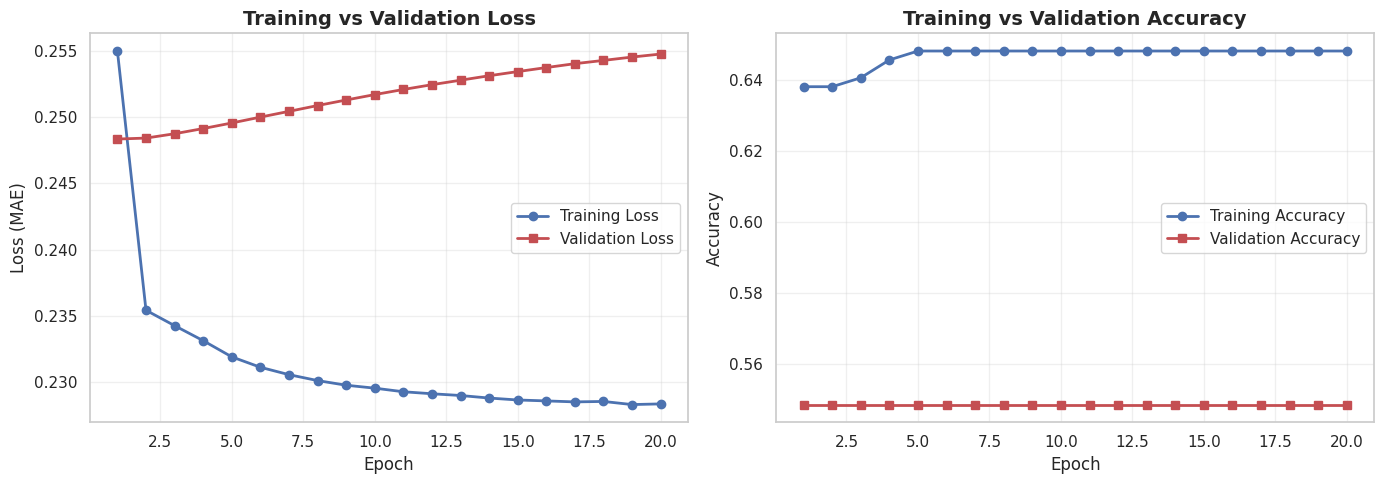

✓ Training curves plotted successfully!

FINAL TESTING EVALUATION

Test Set Results:
  Test Loss (MAE):   0.2310
  Test Accuracy:      0.6379
  Test Error Rate:    0.3621


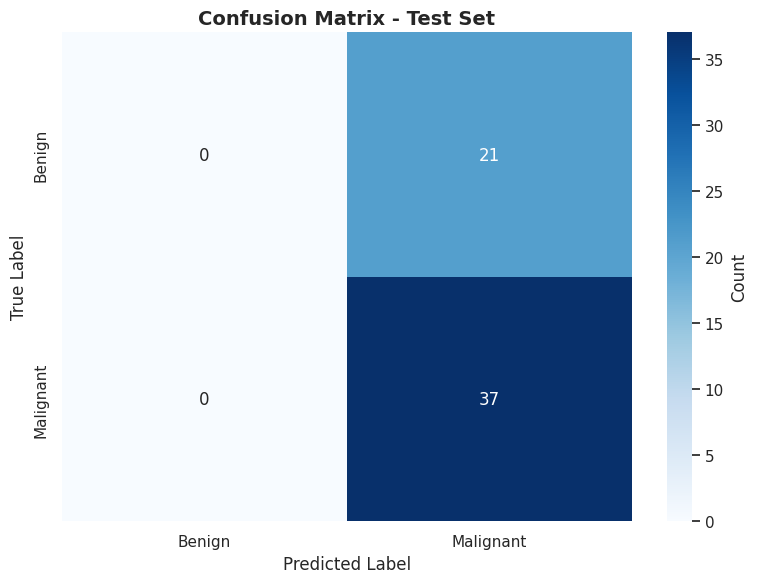

✓ Confusion matrix generated

Additional Metrics:
  Precision: 0.6379
  Recall:    1.0000
  F1-Score:  0.7789


In [50]:
# ==============================================
# TRAINING HISTORY SUMMARY
# ==============================================

print("\n" + "=" * 80)
print("TRAINING HISTORY SUMMARY")
print("=" * 80)

# Create a clear summary table of all metrics recorded during training
history_df = pd.DataFrame({
    "Epoch": range(1, len(nn.train_losses) + 1),
    "Train Loss": nn.train_losses,
    "Train Accuracy": nn.train_accuracies,
    "Val Loss": nn.val_losses,
    "Val Accuracy": nn.val_accuracies
})

# Print the table in nice aligned format
print(history_df.to_string(index=False))
print("=" * 80)

# ==============================================
# TRAINING CURVES (LOSS + ACCURACY)
# ==============================================

plt.figure(figsize=(14, 5))

# ----------------------------------------------------------
# PLOT 1: LOSS CURVES (Training vs Validation)
# ----------------------------------------------------------
plt.subplot(1, 2, 1)

# Training loss curve
plt.plot(
    range(1, len(nn.train_losses) + 1),
    nn.train_losses,
    'b-o',
    label='Training Loss',
    linewidth=2,
    markersize=6
)

# Validation loss curve
plt.plot(
    range(1, len(nn.val_losses) + 1),
    nn.val_losses,
    'r-s',
    label='Validation Loss',
    linewidth=2,
    markersize=6
)

# Labels and title
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss (MAE)", fontsize=12)
plt.title("Training vs Validation Loss", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)


# ----------------------------------------------------------
# PLOT 2: ACCURACY CURVES (Training vs Validation)
# ----------------------------------------------------------
plt.subplot(1, 2, 2)

# Training accuracy curve
plt.plot(
    range(1, len(nn.train_accuracies) + 1),
    nn.train_accuracies,
    'b-o',
    label='Training Accuracy',
    linewidth=2,
    markersize=6
)

# Validation accuracy curve
plt.plot(
    range(1, len(nn.val_accuracies) + 1),
    nn.val_accuracies,
    'r-s',
    label='Validation Accuracy',
    linewidth=2,
    markersize=6
)

# Labels and title
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Training vs Validation Accuracy", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)


# ----------------------------------------------------------
# Final layout + show
# ----------------------------------------------------------
plt.tight_layout()
plt.show()

print("✓ Training curves plotted successfully!")

# ==============================================
# FINAL TESTING EVALUATION
# ==============================================

print("\n" + "=" * 80)
print("FINAL TESTING EVALUATION")
print("=" * 80)

# ----------------------------------------------------------
# STEP 1: Package test features + labels together
# ----------------------------------------------------------
test_data = [X_test, y_test]

# ----------------------------------------------------------
# STEP 2: Compute test loss (MAE)
# ----------------------------------------------------------
test_error_vector, test_loss = test_TestSet_np(test_data, nn)

# ----------------------------------------------------------
# STEP 3: Compute test accuracy
# ----------------------------------------------------------
test_predictions, _ = nn.forward_pass(X_test)
test_accuracy = accuracy_np(test_predictions, y_test)

# ----------------------------------------------------------
# STEP 4: Display results in a clean summary format
# ----------------------------------------------------------
print("\nTest Set Results:")
print(f"  Test Loss (MAE):   {test_loss:.4f}")
print(f"  Test Accuracy:      {test_accuracy:.4f}")
print(f"  Test Error Rate:    {1 - test_accuracy:.4f}")
print("=" * 80)

# =================================================
# CONFUSION MATRIX + PRECISION / RECALL / F1
# =================================================

# -------------------------------------------------
# STEP 1: Get predicted class labels for the test set
# -------------------------------------------------

# Forward pass → get predicted probabilities from the network
test_predictions_prob, _ = nn.forward_pass(X_test)

# For binary classification:
# If probability >= 0.5 → predict class 1 (Malignant)
# If probability <  0.5 → predict class 0 (Benign)
test_predictions_class = (test_predictions_prob >= 0.5).astype(int).flatten()

# Make sure true labels are a 1D integer array (0 or 1)
y_test_class = y_test.flatten().astype(int)

# -------------------------------------------------
# STEP 2: Compute confusion matrix
# -------------------------------------------------
# Confusion matrix layout (for binary classification):
#            Predicted
#            0      1
# True  0   TN     FP
#       1   FN     TP
cm = confusion_matrix(y_test_class, test_predictions_class)

# -------------------------------------------------
# STEP 3: Plot confusion matrix as a heatmap
# -------------------------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,          # write counts inside the boxes
    fmt='d',             # integer format
    cmap='Blues',
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant'],
    cbar_kws={'label': 'Count'}
)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix - Test Set", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Confusion matrix generated")

# -------------------------------------------------
# STEP 4: Derive TN, FP, FN, TP from the confusion matrix
# -------------------------------------------------
tn, fp, fn, tp = cm.ravel()

# -------------------------------------------------
# STEP 5: Compute extra metrics: Precision, Recall, F1
# -------------------------------------------------
# Precision  = TP / (TP + FP)
# Recall     = TP / (TP + FN)
# F1-Score   = 2 * (Precision * Recall) / (Precision + Recall)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score  = (
    2 * (precision * recall) / (precision + recall)
    if (precision + recall) > 0 else 0
)

print("\nAdditional Metrics:")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1_score:.4f}")

# **Section 3**
## **Final Summary Report**

In [51]:
# =================================================
# FINAL PROJECT SUMMARY
# =================================================

print("\n" + "=" * 80)
print("FINAL PROJECT SUMMARY")
print("=" * 80)

# ------------------------------
# Dataset info
# ------------------------------
print("\nDATASET INFORMATION:")
print(f"  Total samples:      {len(df)}")
print(f"  Number of features: {X_train.shape[1]}")
print(f"  Number of classes:  {n_classes}")

# ------------------------------
# Neural network architecture
# ------------------------------
print("\nNETWORK ARCHITECTURE:")
print(f"  Input neurons:       {nn.input_size}")
print(f"  Hidden neurons:      {nn.hidden_size}")
print(f"  Output neurons:      {nn.output_size}")
print(f"  Activation function: {nn.activation_name}")
print(f"  Learning rate:       {nn.learning_rate}")

# ------------------------------
# Training configuration
# ------------------------------
print("\nTRAINING CONFIGURATION:")
print(f"  Training samples:   {len(X_train)} (70%)")
print(f"  Validation samples: {len(X_val)} (20%)")
print(f"  Test samples:       {len(X_test)} (10%)")
print(f"  Total epochs run:   {len(nn.train_losses)}")
print(f"  Batch size:         100")

# ------------------------------
# Final performance metrics
# ------------------------------
print("\nFINAL PERFORMANCE:")
print(f"  Training Accuracy:    {nn.train_accuracies[-1]:.4f}")
print(f"  Validation Accuracy:  {nn.val_accuracies[-1]:.4f}")
print(f"  Test Accuracy:        {test_accuracy:.4f}")
print(f"  Test Loss (MAE):      {test_loss:.4f}")

print("\n" + "=" * 80)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 80)


FINAL PROJECT SUMMARY

DATASET INFORMATION:
  Total samples:      569
  Number of features: 30
  Number of classes:  2

NETWORK ARCHITECTURE:
  Input neurons:       30
  Hidden neurons:      10
  Output neurons:      1
  Activation function: sigmoid
  Learning rate:       0.01

TRAINING CONFIGURATION:
  Training samples:   398 (70%)
  Validation samples: 113 (20%)
  Test samples:       58 (10%)
  Total epochs run:   20
  Batch size:         100

FINAL PERFORMANCE:
  Training Accuracy:    0.6482
  Validation Accuracy:  0.5487
  Test Accuracy:        0.6379
  Test Loss (MAE):      0.2310

PROJECT COMPLETED SUCCESSFULLY
